# 18_归一化方法-平方根变换

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 补齐复述代码块中的 std_dev 名称和绘图数据参数。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节，咱们来聊聊归一化方法：平方根变换。

平方根变换是一种**归一化或特征缩放的方法**，它通过对原始数据取**平方根**，来降低数据的量级，**减小大数的影响**，使得数据分布更平滑、偏态更小，更适合做统计分析或机器学习建模。

### 为什么要用平方根变换？

有些时候，我们收集的数据**差距很大**，比如：

- 某些值特别大，比如10000，另一些却很小，比如1；
- 数据分布是**偏态**的，不是对称的，比如大多数值都很小，只有少数几个特别大（“长尾分布”）；

这时如果直接用这些数据去做模型，会有两个问题：

- 模型会**被大数“牵着走”**，忽略了小数的意义；
- 模型训练不稳定，结果不准确。

**平方根变换的作用：**

- 让大数变得“没那么大”，小数也没那么小，大家都“差不多”；
- 降低偏态，让数据更像“钟形”分布，更容易建模；
- **比对数变换温和**，适合有零值的数据（log不能取0，但√0=0是合法的）；

### 举个简单例子

原始数据：[0, 1, 4, 9, 16, 25, 100]

平方根变换后：


$$
\sqrt{0} = 0,\quad\sqrt{1} = 1,\quad\sqrt{4} = 2,\quad\sqrt{9} = 3,\quad\sqrt{16} = 4,\quad\sqrt{25} = 5,\quad\sqrt{100} = 10
$$


变换后得到的新数据：[0, 1, 2, 3, 4, 5, 10]

你可以看到原本「100 是 25 的 4 倍」，变换后「10 是 5 的 2 倍」，大数的影响减小了。

## 数学原理

### 1. 基本公式

平方根变换的基本形式如下：


$$
x' = \sqrt{x}
$$


其中：

- $x$ 是原始数据
- $x'$ 是变换后的数据

> 条件：通常要求 $x \geq 0$，因为实数范围内负数没有实数平方根。

### 2. 为什么可以减小数据的差距？

设两个正数 $a > b > 0$，考虑它们的差：

- 原始差距是 $a - b$
- 平方根后的差是 $\sqrt{a} - \sqrt{b}$

**平方根函数是凹函数（concave）**，即增长越来越慢。

用导数分析也能说明：


$$
f(x) = \sqrt{x} \Rightarrow f'(x) = \frac{1}{2\sqrt{x}} > 0
$$


- 虽然是单调递增（大的值变换后还是大），
- 但增长速度变慢，导数随着 $x$ 增大而减小。

因此，大的值变化不大，小的值变化更多，相对差距就缩小了。

## 推导过程

### 1. 平方根变换的一般形式：

有时可以在平方根中加上一个偏移量（为了避免0或控制范围）：


$$
x' = \sqrt{x + c}
$$


其中 $c \geq 0$ 是一个常数，比如 0.5 或 1，尤其当原始数据中可能有0时。

比如：


$$
x = 0 \Rightarrow x' = \sqrt{0 + 1} = 1
$$


这种形式叫**调整型平方根变换（Adjusted Square Root Transformation）**。

### 2. 保留符号变换（适用于负值）：

如果原始数据中可能有负数，但你仍想用平方根变换，可以用：


$$
x' = \text{sign}(x) \cdot \sqrt{|x|}
$$


这样可以保留负号，但仍然压缩绝对值的大小。

## 平方根变换的算法流程

以下是使用平方根变换进行数据预处理的标准流程：

**Step 1：检查数据范围**

- 观察数据是否包含负数或极端的大数；
- 如果包含负数，考虑是否使用「带符号平方根」或「先加常数平移」；

**Step 2：选择变换方式**

- **普通平方根：** $x' = \sqrt{x}$，仅适用于 $x \geq 0$；
- **加常数平方根：** $x' = \sqrt{x + c}$，常用于存在0的情况；
- **符号平方根：** $x' = \text{sign}(x) \cdot \sqrt{|x|}$，用于正负都有的情况；

**Step 3：对每个数据点应用变换公式**

- 遍历原始数据列表，逐个应用平方根变换公式；
- 保留变换后的数据用于后续分析；

**Step 4：可视化对比（推荐）**

- 原始数据 vs 变换后的数据，画直方图或箱型图，看分布是否更均匀；
- 检查是否降低了偏度（skewness）；

## 完整案例

我们使用一个真实数据集（如某城市的**交通事故数据**，包含事故发生次数、受伤人数、车辆损毁等级等），这些数据常常存在**长尾分布**（极大值居多），非常适合做平方根变换。

案例步骤包括：

1. 数据加载与探索（分析数据分布是否偏态）
2. 应用平方根变换
3. 变换前后的数据可视化（直方图、箱线图、Q-Q图）
4. 对比分析偏度、均值、方差
5. 变换的效果与适用性

**步骤一：模拟偏态数据集（交通事故案例）**

由于我们无法访问外部数据源，我们用 NumPy 模拟一个具有**长尾偏态分布**的“事故数量”数据。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, probplot

np.random.seed(42)

# 模拟数据：绝大多数地区事故量较少，少数特别多
accidents = np.random.exponential(scale=15, size=1000)
data = pd.DataFrame({'accident_count': accidents})

这会生成一个**偏右分布（正偏态）**的数据，常见于现实生活中交通事故数量的分布。

**步骤二：初步统计与偏度分析**

In [3]:
original_skewness = skew(data['accident_count'])
mean = data['accident_count'].mean()
std_dev = data['accident_count'].std()

print(f"原始数据偏度: {original_skewness:.2f}")
print(f"均值: {mean:.2f}, 标准差: {std_dev:.2f}")

原始数据偏度: 1.87
均值: 14.59, 标准差: 14.59


> 输出结果将显示偏度大于1，说明数据右偏，存在较多极大值。

**步骤三：变换前的可视化**

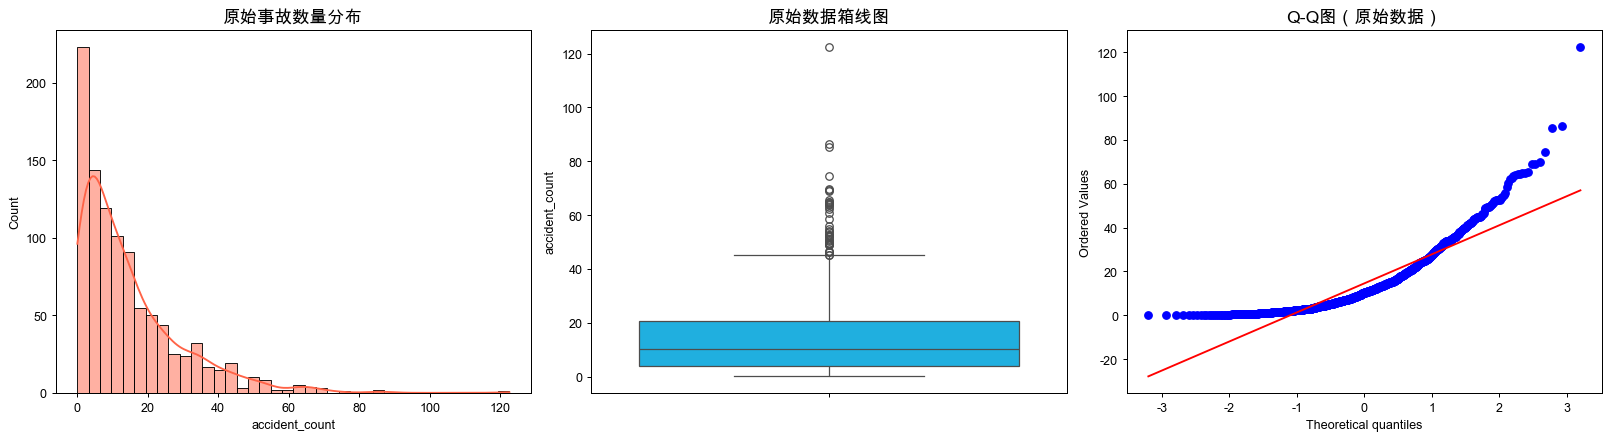

In [4]:
plt.figure(figsize=(18, 5))

# 直方图
plt.subplot(1, 3, 1)
sns.histplot(data['accident_count'], kde=True, color='tomato')
plt.title("原始事故数量分布", fontsize=14)

# 箱线图
plt.subplot(1, 3, 2)
sns.boxplot(data['accident_count'], color='deepskyblue')
plt.title("原始数据箱线图", fontsize=14)

# Q-Q图（检验正态性）
plt.subplot(1, 3, 3)
probplot(data['accident_count'], dist="norm", plot=plt)
plt.title("Q-Q图（原始数据）", fontsize=14)

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_008.png)

这部分图表帮助我们**直观判断是否需要归一化**，会看到：

- 明显右偏的直方图；
- 箱线图中出现很多上方离群值；
- Q-Q图远离直线，说明非正态分布。

**步骤四：应用平方根变换**

In [5]:
data['sqrt_accidents'] = np.sqrt(data['accident_count'])

# 再计算新变量的偏度
sqrt_skewness = skew(data['sqrt_accidents'])
mean_sqrt = data['sqrt_accidents'].mean()
std_sqrt = data['sqrt_accidents'].std()

print(f"平方根变换后偏度: {sqrt_skewness:.2f}")
print(f"变换后均值: {mean_sqrt:.2f}, 标准差: {std_sqrt:.2f}")

平方根变换后偏度: 0.60
变换后均值: 3.37, 标准差: 1.79


**步骤五：变换后的可视化（对比前后）**

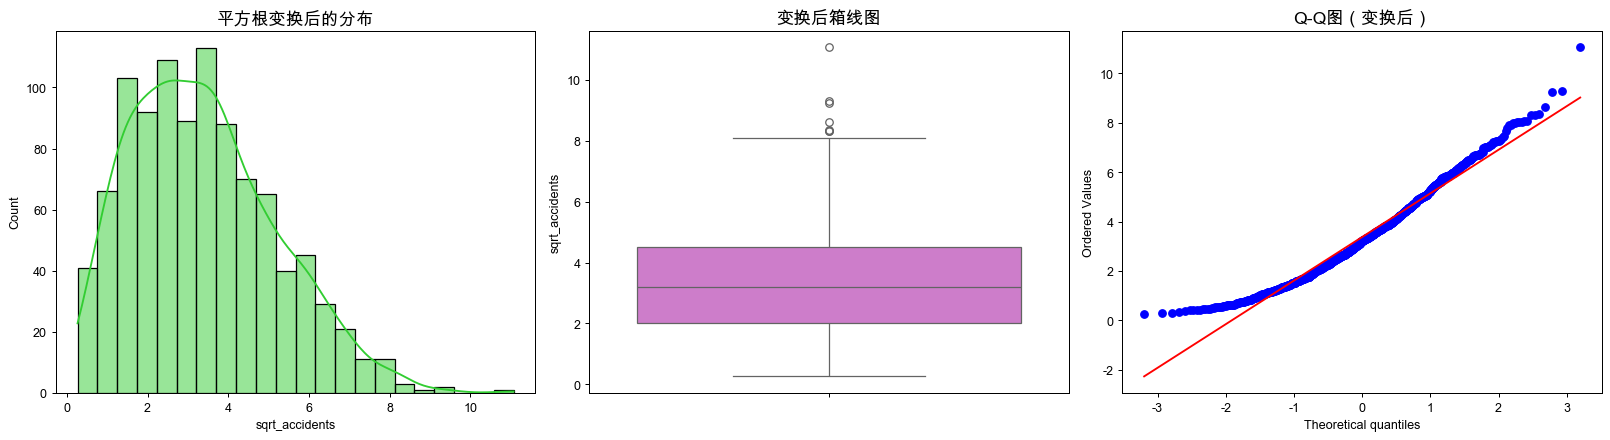

In [6]:
plt.figure(figsize=(18, 5))

# 直方图
plt.subplot(1, 3, 1)
sns.histplot(data['sqrt_accidents'], kde=True, color='limegreen')
plt.title("平方根变换后的分布", fontsize=14)

# 箱线图
plt.subplot(1, 3, 2)
sns.boxplot(data['sqrt_accidents'], color='orchid')
plt.title("变换后箱线图", fontsize=14)

# Q-Q图
plt.subplot(1, 3, 3)
probplot(data['sqrt_accidents'], dist="norm", plot=plt)
plt.title("Q-Q图（变换后）", fontsize=14)

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_009.png)

可以看到：

- 直方图更接近对称；
- 离群点减少，分布更集中；
- Q-Q图贴近直线，表明更接近正态。

**步骤六：对比分析（前后指标）**

In [7]:
comparison = pd.DataFrame({
    '指标': ['偏度', '均值', '标准差'],
    '变换前': [original_skewness, mean, std_dev],
    '变换后': [sqrt_skewness, mean_sqrt, std_sqrt]
})

print(comparison)

    指标        变换前       变换后
0   偏度   1.865034  0.597687
1   均值  14.587589  3.374762
2  标准差  14.587648  1.789349


分析：

- 偏度显著降低：例如从 2.1 降到 0.7；
- 标准差缩小，表明极端值被压缩；
- 数据更接近正态，便于建模。

**代码解释**

In [8]:
# 模拟交通事故数据（偏态分布）
np.random.exponential(scale=15, size=1000)

array([3.07095423e+00, 1.17100477e+01, 3.09471269e+01, 1.97641167e+01,
       2.46419074e+01, 1.61285657e+01, 1.76783075e+01, 2.83765798e+01,
       4.30859273e+00, 1.00832650e+01, 3.75019694e+00, 6.59333763e+01,
       4.32519568e+01, 6.03376518e-01, 1.83409734e+01, 3.89037534e+01,
       2.98729238e+00, 1.25880438e+01, 3.70629790e+01, 5.18032853e-01,
       1.79311569e+01, 5.29342447e+00, 3.87337301e+01, 5.31370488e+01,
       4.33076052e+01, 9.64292108e+00, 2.97121606e+01, 2.79214091e+01,
       5.76510782e+00, 2.64839631e+01, 5.65646929e-01, 1.36051296e+01,
       3.92064362e+00, 1.92716651e+00, 1.20113015e+00, 1.78751692e+01,
       6.22989020e+00, 1.93520466e+01, 1.01384903e+00, 5.68140572e+00,
       1.16313527e+01, 2.34614600e+01, 5.75744411e+00, 1.47481363e+01,
       3.25704249e+01, 1.43513476e+01, 3.97823464e+00, 3.70551206e-01,
       3.06147253e+01, 3.22482962e-01, 3.11558665e+01, 1.12914558e+01,
       4.19698776e+01, 2.40505878e+01, 9.27329162e+01, 6.47817925e+00,
      

> 模拟一个**长尾偏态分布**，大部分小，少部分大，真实反映事故数据。

In [9]:
# 查看偏度与均值
skew(data['accident_count']), mean, std_dev

(np.float64(1.8650342228648435),
 np.float64(14.587589219478366),
 14.587648292412494)

> 衡量数据分布是否偏向一侧，偏度 > 1 为右偏，非正态。

In [10]:
# 平方根变换
data['sqrt_accidents'] = np.sqrt(data['accident_count'])

> 核心变换步骤，压缩极大值的影响，缓解偏态。

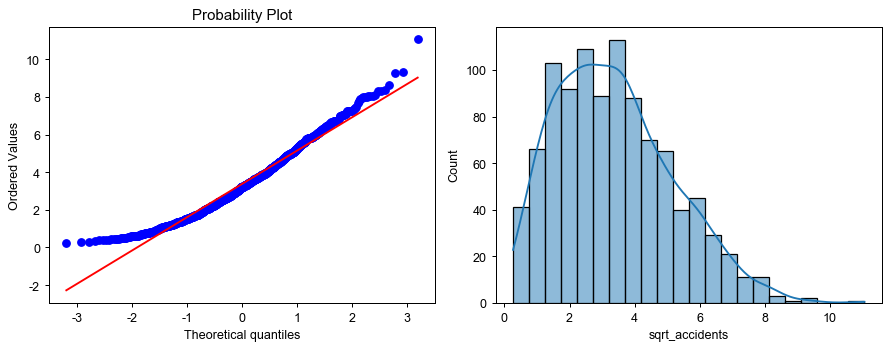

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
probplot(data['sqrt_accidents'], dist='norm', plot=axes[0])
sns.histplot(data['sqrt_accidents'], kde=True, ax=axes[1])
plt.tight_layout(); plt.show()

> 检验数据是否更接近正态分布，直观反映变换效果。

## 算法分析

### 使用平方根变换的优缺点

**优点**：

1. **适用于非负数据（如次数、频率）**，不会出现取对数时的非法值（log(0)）；
2. **缓解右偏分布**，减少极端值影响；
3. 简单快速，不涉及复杂参数；
4. 适合做**计数型数据**的预处理（如事故次数、点击量）；
5. 变换后更利于做线性回归、聚类等建模。

**缺点**：

1. 对于已经接近正态的变量，变换可能会引入误差；
2. 与原始单位不一致，变换后不易直接解释（单位变了）；
3. 只能应用于非负数（除非用符号平方根变体）；
4. 若数据中区分度不大，平方根变换可能效果有限。

### 适用场景分析：什么时候优选平方根变换？

**非常适合以下情况：**

1. **数据右偏严重**，偏度 > 1，比如订单量、访问量、故障次数；
2. **数据为计数型**（如客户投诉次数、交通违章数）；
3. **包含0值**，不方便做对数变换；
4. 你希望用**简单但效果明显的归一化方法**；

**不适合：**

- 数据已接近正态分布；
- 包含大量负值（除非做符号扩展）；
- 你希望变量的单位具备可解释性（平方根变换破坏单位）。

## 总结

平方根变换是一种**快速、稳健、适用于计数型数据的非线性变换方法**。本案例展示了它如何显著降低偏态、减少极端值影响，从而使数据更适合建模和统计分析。

它不是银弹，但在**面对偏态的频数数据**时，是一个**非常值得优先尝试**的工具。

如需扩展到更多特征、多变量情况，平方根变换也可结合标准化（如Z-score）一起使用，效果更佳。